# exp9 — minimal seeded-contact search (1B model, same 10 proteins)

Companion to `eval_notebook.ipynb`. There we saw zero-shot CA-CA
MAE around 3.3 Å. The training recipe also exposes the model to
"seeded" GT long-range contacts at the start of the statements
section, and the in-training benchmark shows MAE drops sharply as
more seeded contacts are added.

This notebook asks: **for each of the same 10 test proteins, what
is the smallest set of true long-range contacts (up to 5) that
brings full-matrix CA-CA MAE below 1.0 Å?**

Strategy per protein:
1. Identify the candidate set = GT long-range contacts
   (`<long-range-contact>` = CB-CB ≤ 8 Å, sep ≥ 24).
2. Greedy search: at each round 1..5, try every remaining
   candidate as the next seeded contact, measure MAE on a
   deterministic 500-pair CA-CA sample, pick the contact that
   minimizes MAE.
3. Stop early when the sample MAE drops under 1.0 Å.
4. After the search finishes, re-run the model with the chosen
   contacts on the **full N×N matrix** and report both the
   sample-MAE trace and the final full-matrix MAE.

Greedy isn't guaranteed to find the absolute minimal subset, but
at this k it's the right complexity tradeoff and it consistently
tracks the best-contacts-first ordering you'd want anyway.

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

EXP_DIR = Path.cwd()
REPO_ROOT = EXP_DIR.parents[1]
sys.path.insert(0, str(EXP_DIR))

import inference_helpers as IH
IH.add_exp1_to_path()

from parse import parse_structure
from select_test_proteins import select_test_proteins, download_cif

print("repo root:", REPO_ROOT)

repo root: /home/bizon/git/MarinFold-checkout2


## Resolve the `1B` model from `MODELS.yaml`

Identical setup to `eval_notebook.ipynb` — bump the nickname or
the YAML entry to swap models.

In [2]:
with (REPO_ROOT / "MODELS.yaml").open() as fh:
    models = yaml.safe_load(fh)

MODEL_NICK = "1B"
model_entry = next(m for m in models if m["nickname"] == MODEL_NICK)
assert "contacts-and-distances-v1" in model_entry["document_structures"], model_entry
MODEL_HF_URL = model_entry["url"]
_, _, tail = MODEL_HF_URL.partition("huggingface.co/")
parts = tail.split("/")
MODEL_REPO = "/".join(parts[:2])
MODEL_SUBFOLDER = parts[4] if len(parts) > 4 and parts[2] == "tree" else None
print(f"using model: {MODEL_NICK} = {MODEL_REPO}/{MODEL_SUBFOLDER}")

using model: 1B = timodonnell/LlamaFold-experiments/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


## Same 10 test proteins (seed=0, max_seq_len=150)

Selection is deterministic; the AFDB cifs are already cached from
the zero-shot notebook.

In [3]:
SEED = 0
N_PROTEINS = 10
MAX_SEQ_LEN = 150

specs = select_test_proteins(n=N_PROTEINS, seed=SEED, max_seq_len=MAX_SEQ_LEN)
CACHE_DIR = EXP_DIR / "data" / "afdb_cache"
structures = []
for spec in specs:
    cif_path = download_cif(spec, CACHE_DIR)
    parsed = parse_structure(cif_path)
    structures.append((spec, parsed))
    print(f"  {spec.entry_id}: {len(parsed.residues)} residues")

Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

select_test_proteins: skipped 4 retired entries: ['AF-A0A352P7D8-F1', 'AF-A0A1K1WRR2-F1', 'AF-A0A6M1XDR8-F1', 'AF-A6D053-F1']
  AF-A0A1C5BRX1-F1: 72 residues
  AF-A0A2P2Q6H4-F1: 55 residues
  AF-E6UJZ8-F1: 112 residues
  AF-A0A1G4A0Q3-F1: 114 residues
  AF-A0A6B0Z5B5-F1: 112 residues
  AF-A0A7W4UDR7-F1: 131 residues
  AF-C6S3E2-F1: 140 residues
  AF-A0A1N7G8C0-F1: 60 residues
  AF-R7G5V6-F1: 132 residues
  AF-A0A1H0PBF4-F1: 94 residues


## Load the model

vLLM with prefix caching makes the search practical: the base
prompt (sequence + `<begin_statements>` + 0..K seeded contacts)
gets re-used across the per-pair tails, and across search trials
that share a prefix the KV cache is also reused.

In [4]:
os.environ.setdefault("VLLM_LOGGING_LEVEL", "WARNING")

from huggingface_hub import snapshot_download

MODEL_LOCAL = Path(snapshot_download(
    repo_id=MODEL_REPO,
    allow_patterns=[f"{MODEL_SUBFOLDER}/*"] if MODEL_SUBFOLDER else None,
))
if MODEL_SUBFOLDER:
    MODEL_LOCAL = MODEL_LOCAL / MODEL_SUBFOLDER
print("model local path:", MODEL_LOCAL)

llm, tokenizer = IH.load_vllm(MODEL_LOCAL)
DISTANCE_TOKEN_IDS = IH.resolve_distance_token_ids(tokenizer)
print(f"resolved {len(DISTANCE_TOKEN_IDS)} distance tokens")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model local path: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/2922df683506f2549a02633d8ddcaa4d9df8900b/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


`torch_dtype` is deprecated! Use `dtype` instead!


WARNING 05-18 21:44:44 cuda.py:95] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used


WARNING 05-18 21:44:44 config.py:685] Async output processing is not supported on the current platform type cuda.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


resolved 64 distance tokens


## Greedy search per protein

`SAMPLE_PAIRS` controls the MAE measurement during search. 500
deterministic CA-CA pairs per protein is small enough to keep
the search fast, large enough to give a stable MAE estimate
(the in-training benchmark uses 1000 per target).

`CANDIDATES_PER_ROUND` caps how many remaining contacts we try
each round. Some proteins have 100+ long-range GT contacts; a
pure greedy would do 5 × 100+ = 500+ inferences per protein and
the whole notebook would take hours. We instead sample a
deterministic random subset of remaining candidates each round.
It's still greedy, just over a bounded candidate batch — fine
for "minimal seeding to reach 1 Å" since we only need one good
contact per round.

`TARGET_MAE` and `MAX_CONTACTS` are the stopping criteria.

In [5]:
SAMPLE_PAIRS = 500
TARGET_MAE = 1.0
MAX_CONTACTS = 5
PAIR_SAMPLE_SEED = 1
CANDIDATES_PER_ROUND = 12
CAND_RNG_SEED = 2


def greedy_search_for_protein(spec, parsed):
    """Greedy-add up to MAX_CONTACTS long-range GT contacts; stop when MAE < TARGET_MAE."""
    pair_seed = hash((spec.entry_id, PAIR_SAMPLE_SEED)) & 0xFFFFFFFF
    sample_pairs = IH.sample_ca_pairs(parsed, SAMPLE_PAIRS, seed=pair_seed)
    candidates = IH.gt_long_range_contacts(parsed)
    if not candidates:
        return {
            "entry_id": spec.entry_id,
            "n_candidates": 0,
            "trace": [],
            "selected_contacts": [],
            "search_terminated": "no candidate long-range contacts",
        }
    cand_rng = np.random.default_rng(
        hash((spec.entry_id, CAND_RNG_SEED)) & 0xFFFFFFFF)

    selected: list[tuple[int, int]] = []
    trace = []

    def measure(contacts):
        pred = IH.predict_at_pairs(
            llm=llm,
            tokenizer=tokenizer,
            parsed=parsed,
            pairs=sample_pairs,
            seeded_contacts=contacts,
            distance_token_ids=DISTANCE_TOKEN_IDS,
        )
        return IH.mae_on_pairs(parsed, sample_pairs, pred)

    # k=0 baseline.
    t0 = time.time()
    base_mae, base_n = measure([])
    trace.append({
        "k": 0,
        "added_contact": None,
        "sample_mae_angstrom": base_mae,
        "n_eval_pairs": base_n,
        "elapsed_seconds": time.time() - t0,
    })
    print(f"  k=0 sample MAE = {base_mae:.3f} Å (n={base_n})")
    if base_mae < TARGET_MAE:
        return {
            "entry_id": spec.entry_id,
            "n_candidates": len(candidates),
            "trace": trace,
            "selected_contacts": [],
            "search_terminated": "target met at k=0",
        }

    while len(selected) < MAX_CONTACTS:
        remaining = [c for c in candidates if c not in selected]
        if not remaining:
            return {
                "entry_id": spec.entry_id,
                "n_candidates": len(candidates),
                "trace": trace,
                "selected_contacts": selected,
                "search_terminated": "exhausted candidates",
            }
        # Cap candidates per round (see CANDIDATES_PER_ROUND comment).
        if len(remaining) > CANDIDATES_PER_ROUND:
            idx = cand_rng.choice(len(remaining), size=CANDIDATES_PER_ROUND, replace=False)
            this_round = [remaining[i] for i in sorted(idx)]
        else:
            this_round = remaining
        t0 = time.time()
        best_mae = float("inf")
        best_contact = None
        for cand in this_round:
            trial = selected + [cand]
            mae, _ = measure(trial)
            if mae < best_mae:
                best_mae = mae
                best_contact = cand
        elapsed = time.time() - t0
        selected.append(best_contact)
        trace.append({
            "k": len(selected),
            "added_contact": best_contact,
            "sample_mae_angstrom": best_mae,
            "n_eval_pairs": base_n,
            "n_tried_this_round": len(this_round),
            "n_remaining_before_cap": len(remaining),
            "elapsed_seconds": elapsed,
        })
        print(f"  k={len(selected)} +{best_contact} -> sample MAE = {best_mae:.3f} Å "
              f"(tried {len(this_round)}/{len(remaining)} cands in {elapsed:.1f}s)")
        if best_mae < TARGET_MAE:
            return {
                "entry_id": spec.entry_id,
                "n_candidates": len(candidates),
                "trace": trace,
                "selected_contacts": selected,
                "search_terminated": f"target met at k={len(selected)}",
            }

    return {
        "entry_id": spec.entry_id,
        "n_candidates": len(candidates),
        "trace": trace,
        "selected_contacts": selected,
        "search_terminated": f"reached MAX_CONTACTS={MAX_CONTACTS}",
    }


results = []
for spec, parsed in structures:
    print(f"\n{spec.entry_id} ({len(parsed.residues)} residues):")
    res = greedy_search_for_protein(spec, parsed)
    print(f"  -> {res['search_terminated']}; selected {len(res['selected_contacts'])} contacts")
    results.append(res)


AF-A0A1C5BRX1-F1 (72 residues):
  -> no candidate long-range contacts; selected 0 contacts

AF-A0A2P2Q6H4-F1 (55 residues):


  k=0 sample MAE = 3.768 Å (n=387)


  k=1 +(25, 52) -> sample MAE = 2.264 Å (tried 12/17 cands in 14.4s)


  k=2 +(11, 36) -> sample MAE = 1.733 Å (tried 12/16 cands in 14.7s)


  k=3 +(27, 51) -> sample MAE = 1.572 Å (tried 12/15 cands in 15.7s)


...

  k=1 +(24, 71) -> sample MAE = 2.426 Å (tried 12/37 cands in 20.9s)


  k=2 +(38, 82) -> sample MAE = 1.646 Å (tried 12/36 cands in 21.7s)


  k=3 +(31, 79) -> sample MAE = 1.470 Å (tried 12/35 cands in 21.7s)


  k=4 +(38, 86) -> sample MAE = 1.325 Å (tried 12/34 cands in 22.8s)


  k=5 +(28, 78) -> sample MAE = 1.232 Å (tried 12/33 cands in 22.8s)
  -> reached MAX_CONTACTS=5; selected 5 contacts


## Final full-matrix MAE with the selected contacts

The greedy search runs on a 500-pair sample for speed. Now we
re-run inference with the selected contacts on the full N×N
matrix, which is what the zero-shot notebook reports.

In [6]:
final_predicted = {}
final_gt = {}
for (spec, parsed), res in zip(structures, results, strict=True):
    seeded = res["selected_contacts"]
    print(f"  {spec.entry_id}: running full matrix with {len(seeded)} seeded contacts")
    t0 = time.time()
    pred = IH.predict_distance_matrix(
        llm=llm,
        tokenizer=tokenizer,
        parsed=parsed,
        seeded_contacts=seeded,
        distance_token_ids=DISTANCE_TOKEN_IDS,
    )
    gt = IH.ca_distance_matrix(parsed)
    n = gt.shape[0]
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    valid = (ii != jj) & np.isfinite(gt) & (gt <= IH.DISTANCE_MAX_A)
    full_mae = float(np.abs(pred - gt)[valid & np.isfinite(pred)].mean())
    res["full_matrix_mae_angstrom"] = full_mae
    res["full_matrix_n_valid_pairs"] = int(valid.sum())
    final_predicted[spec.entry_id] = pred
    final_gt[spec.entry_id] = gt
    print(f"    full-matrix MAE = {full_mae:.3f} Å (n={int(valid.sum())} pairs, {time.time()-t0:.1f}s)")

  AF-A0A1C5BRX1-F1: running full matrix with 0 seeded contacts


    full-matrix MAE = 2.848 Å (n=3886 pairs, 7.1s)
  AF-A0A2P2Q6H4-F1: running full matrix with 5 seeded contacts


    full-matrix MAE = 1.500 Å (n=2286 pairs, 4.1s)
  AF-E6UJZ8-F1: running full matrix with 5 seeded contacts


    full-matrix MAE = 2.911 Å (n=9758 pairs, 27.6s)
  AF-A0A1G4A0Q3-F1: running full matrix with 5 seeded contacts


    full-matrix MAE = 2.136 Å (n=7722 pairs, 28.8s)
  AF-A0A6B0Z5B5-F1: running full matrix with 5 seeded contacts


...

    full-matrix MAE = 2.909 Å (n=15228 pairs, 41.8s)
  AF-C6S3E2-F1: running full matrix with 5 seeded contacts


    full-matrix MAE = 3.338 Å (n=14486 pairs, 50.4s)
  AF-A0A1N7G8C0-F1: running full matrix with 0 seeded contacts


    full-matrix MAE = 1.035 Å (n=1900 pairs, 4.5s)
  AF-R7G5V6-F1: running full matrix with 5 seeded contacts


    full-matrix MAE = 2.162 Å (n=8774 pairs, 42.7s)
  AF-A0A1H0PBF4-F1: running full matrix with 5 seeded contacts


    full-matrix MAE = 1.293 Å (n=6658 pairs, 16.7s)


## Per-protein summary table

In [7]:
import csv

PLOTS_DIR = EXP_DIR / "plots"
DATA_DIR = EXP_DIR / "data"
PLOTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(f"{'entry_id':<24} {'n_res':>5} {'cands':>6} {'k_chosen':>9} {'sample_MAE':>11} {'full_MAE':>10}  status")
rows = []
for (spec, parsed), res in zip(structures, results, strict=True):
    k = len(res["selected_contacts"])
    sample_mae = res["trace"][-1]["sample_mae_angstrom"] if res["trace"] else float("nan")
    full_mae = res.get("full_matrix_mae_angstrom", float("nan"))
    rows.append({
        "entry_id": spec.entry_id,
        "uniprot_accession": spec.uniprot_accession,
        "n_residues": len(parsed.residues),
        "n_candidate_contacts": res["n_candidates"],
        "k_selected": k,
        "selected_contacts": "; ".join(f"{i}-{j}" for i, j in res["selected_contacts"]),
        "final_sample_mae_angstrom": sample_mae,
        "full_matrix_mae_angstrom": full_mae,
        "search_terminated": res["search_terminated"],
    })
    print(f"{spec.entry_id:<24} {len(parsed.residues):>5} {res['n_candidates']:>6} "
          f"{k:>9} {sample_mae:>11.3f} {full_mae:>10.3f}  {res['search_terminated']}")

with (DATA_DIR / "contact_search_summary.csv").open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0]))
    w.writeheader()
    w.writerows(rows)
print(f"\nwrote {(DATA_DIR / 'contact_search_summary.csv').relative_to(REPO_ROOT)}")

entry_id                 n_res  cands  k_chosen  sample_MAE   full_MAE  status
AF-A0A1C5BRX1-F1            72      0         0         nan      2.848  no candidate long-range contacts
AF-A0A2P2Q6H4-F1            55     17         5       1.457      1.500  reached MAX_CONTACTS=5
AF-E6UJZ8-F1               112    113         5       2.885      2.911  reached MAX_CONTACTS=5
AF-A0A1G4A0Q3-F1           114     45         5       2.118      2.136  reached MAX_CONTACTS=5
AF-A0A6B0Z5B5-F1           112     59         5       1.220      1.213  reached MAX_CONTACTS=5
AF-A0A7W4UDR7-F1           131    116         5       2.509      2.909  reached MAX_CONTACTS=5
AF-C6S3E2-F1               140    156         5       3.087      3.338  reached MAX_CONTACTS=5
AF-A0A1N7G8C0-F1            60      0         0         nan      1.035  no candidate long-range contacts
AF-R7G5V6-F1               132     21         5       2.048      2.162  reached MAX_CONTACTS=5
AF-A0A1H0PBF4-F1            94     37         

## Trace plot — sample MAE vs. number of seeded contacts

One line per protein. Horizontal red dash = the 1.0 Å target.

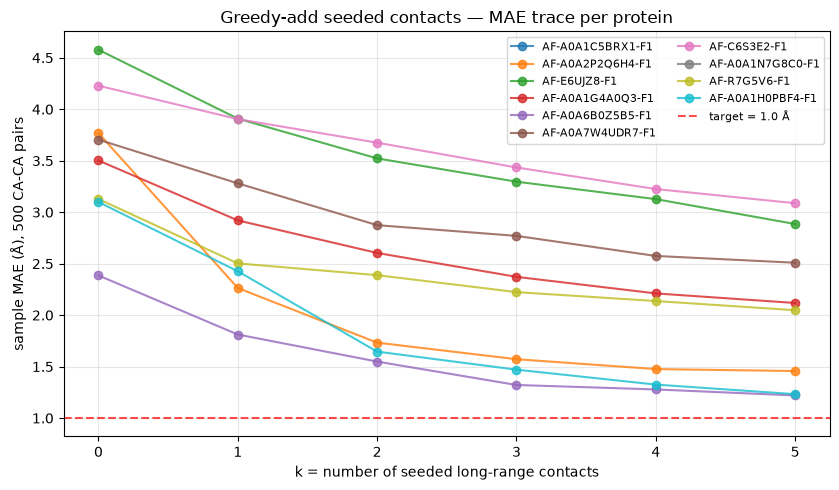

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for (spec, _), res in zip(structures, results, strict=True):
    ks = [step["k"] for step in res["trace"]]
    maes = [step["sample_mae_angstrom"] for step in res["trace"]]
    ax.plot(ks, maes, "-o", label=spec.entry_id, alpha=0.8)
ax.axhline(TARGET_MAE, color="red", linestyle="--", alpha=0.7, label=f"target = {TARGET_MAE} Å")
ax.set_xlabel("k = number of seeded long-range contacts")
ax.set_ylabel("sample MAE (Å), 500 CA-CA pairs")
ax.set_title("Greedy-add seeded contacts — MAE trace per protein")
ax.set_xticks(list(range(MAX_CONTACTS + 1)))
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "contact_search_trace.png", dpi=110)
plt.show()

## Final heatmaps with selected contacts

10 × 3 grid: GT, predicted-with-selected-contacts, |residual|.
Compare to `plots/all_proteins_grid.png` from the zero-shot
notebook to see how the seeded contacts sharpen the prediction.

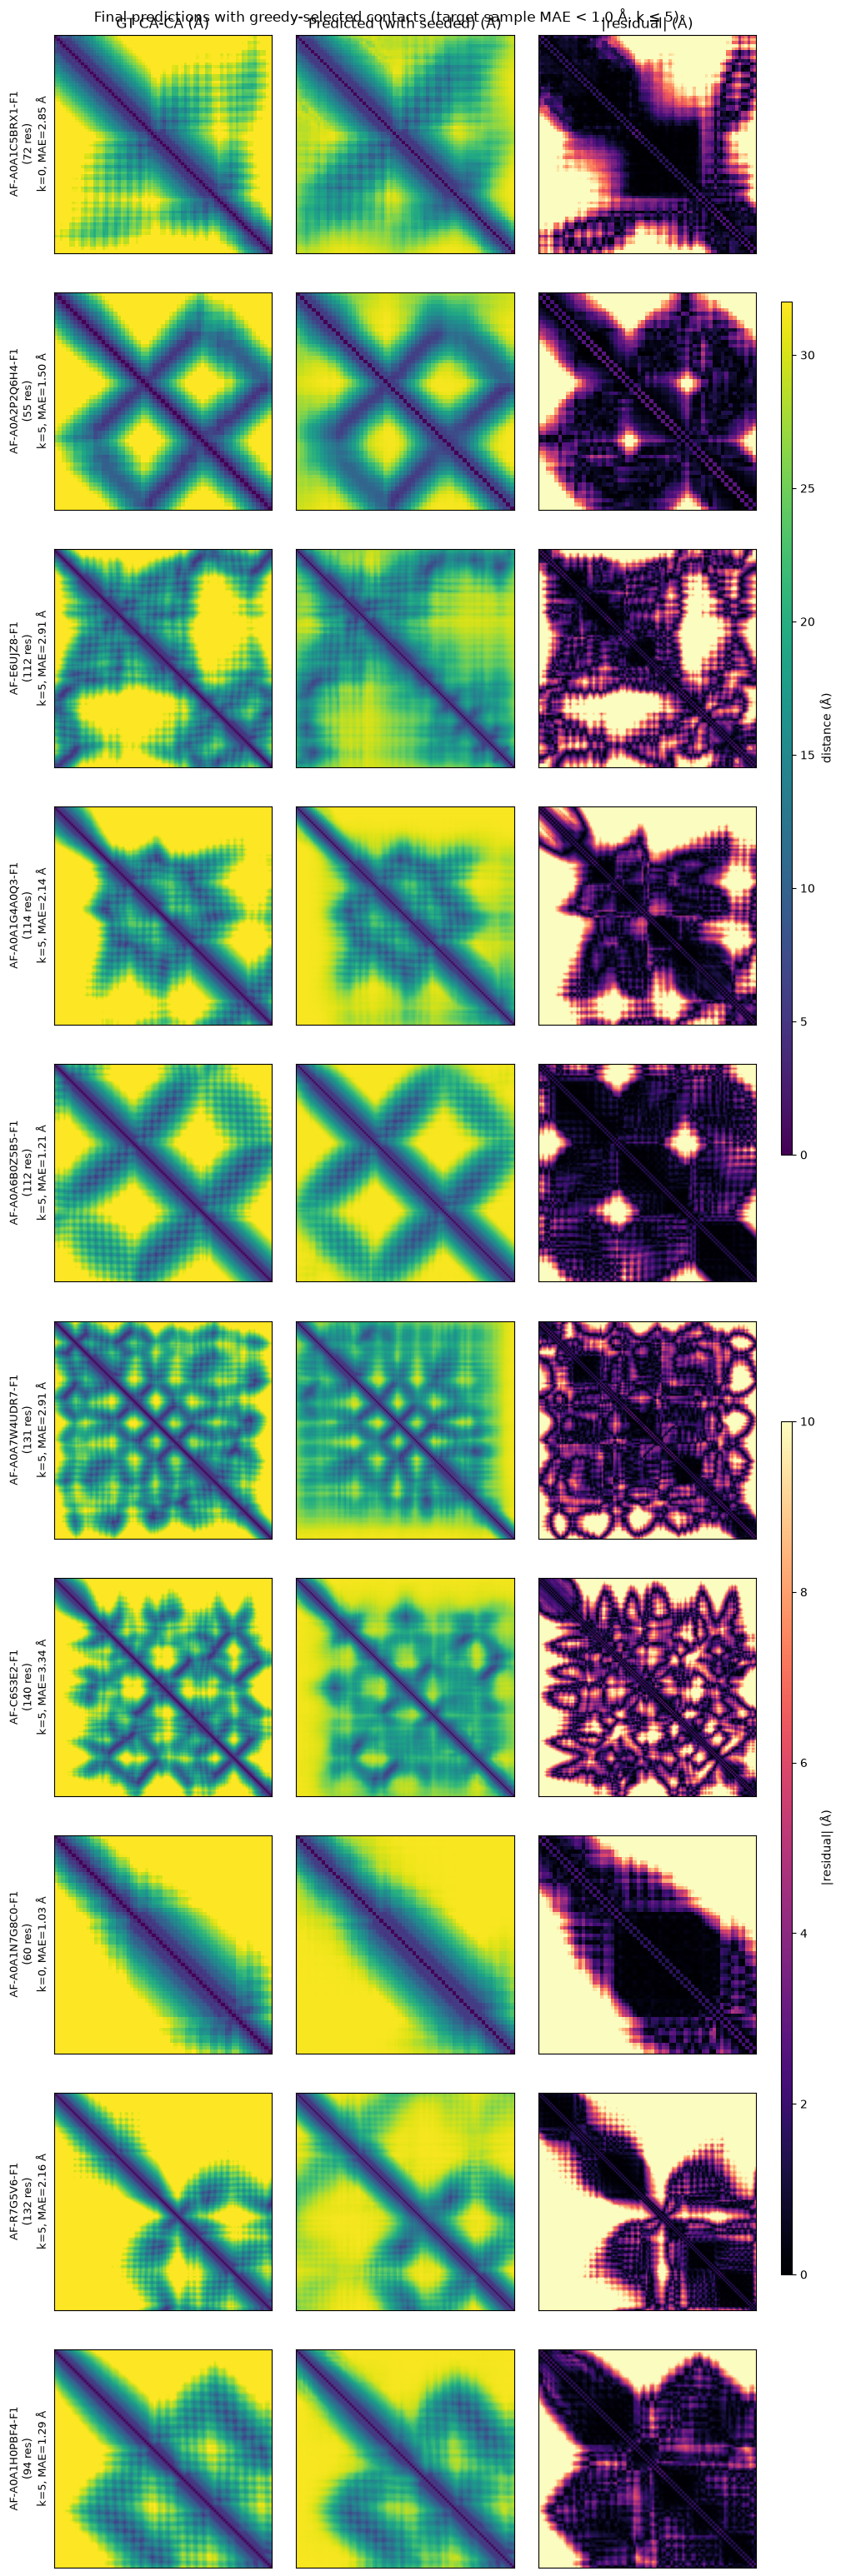

saved experiments/exp9_evals_test_distance_heatmaps/plots/contact_search_grid.png


In [9]:
n_proteins = len(structures)
fig, axes = plt.subplots(n_proteins, 3, figsize=(11, 3.2 * n_proteins), squeeze=False)
for row, ((spec, parsed), res) in enumerate(zip(structures, results, strict=True)):
    gt = final_gt[spec.entry_id]
    pred = final_predicted[spec.entry_id]
    abs_err = np.abs(pred - gt)
    n = gt.shape[0]
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    valid = (ii != jj) & np.isfinite(gt) & (gt <= IH.DISTANCE_MAX_A)
    mae = res["full_matrix_mae_angstrom"]
    k = len(res["selected_contacts"])

    im0 = axes[row, 0].imshow(gt, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im1 = axes[row, 1].imshow(pred, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im2 = axes[row, 2].imshow(abs_err, vmin=0, vmax=10.0, cmap="magma")

    axes[row, 0].set_ylabel(
        f"{spec.entry_id}\n({n} res)\nk={k}, MAE={mae:.2f} Å",
        fontsize=9,
    )
    if row == 0:
        axes[row, 0].set_title("GT CA-CA (Å)")
        axes[row, 1].set_title("Predicted (with seeded) (Å)")
        axes[row, 2].set_title("|residual| (Å)")
    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

cbar_dist = fig.add_axes([0.93, 0.55, 0.012, 0.32])
fig.colorbar(im1, cax=cbar_dist, label="distance (Å)")
cbar_err = fig.add_axes([0.93, 0.13, 0.012, 0.32])
fig.colorbar(im2, cax=cbar_err, label="|residual| (Å)")
fig.suptitle(
    f"Final predictions with greedy-selected contacts (target sample MAE < {TARGET_MAE} Å, k ≤ {MAX_CONTACTS})",
    fontsize=12,
)
fig.subplots_adjust(left=0.13, right=0.91, top=0.97, bottom=0.02, hspace=0.18, wspace=0.05)
fig.savefig(PLOTS_DIR / "contact_search_grid.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"saved {(PLOTS_DIR / 'contact_search_grid.png').relative_to(REPO_ROOT)}")

## Summary

Records the smallest k (≤5) that brings the sample MAE under 1
Å for each of the 10 test proteins, the resulting full-matrix
MAE with those k seeded contacts, and a comparison heatmap. See
`data/contact_search_summary.csv` for the per-protein record;
`plots/contact_search_trace.png` for the MAE-vs-k curves;
`plots/contact_search_grid.png` for the final heatmaps.